# 01 · Análisis Exploratorio de Datos

**Objetivo:** Entender el dataset HAM10000 antes de modelar.

**Datos de entrada:** `../data/raw/HAM10000_metadata.csv`, `../data/raw/hnmist_28_28_RGB.csv`

**Resultado esperado:** Comprensión de la distribución de clases, valores nulos, tipos de variables y aspecto visual de las imágenes.

El objetivo de este trabajo consiste en resolver un problema del mundo real empleando para 
ello técnicas vistas durante las sesiones de dicho módulo. En concreto, se trabajará en 
predecir la condición médica sufrida por una cohorte de pacientes a partir de las diferentes 
fuentes de información disponibles (imágenes y datos tabulares). 

El primer paso sería crear un diccionario de columnas:
| Columna      | Descripción                                                             |
| ------------ | ----------------------------------------------------------------------- |
| lesion_id    | Identificador único de la lesión                                        |
| image_id     | Identificador único de la imagen asociada a la lesión                   |
| dx           | Diagnóstico de la lesión (código de enfermedad, ej. nv, mel, bkl, etc.) |
| dx_type      | Tipo de diagnóstico (ej. histopatológico, clínico, confocal)            |
| age          | Edad del paciente en años                                               |
| sex          | Sexo del paciente (male/female/unknown)                                 |
| localization | Localización de la lesión en el cuerpo                                  |
| dataset      | Conjunto de datos de origen de la imagen/lesión                         |

Tras observar el dataset, también hacemos una pequeña observación de las enfermedades estudiadas, para lo cual creamos el siguiente "diccionario", añadiendo el número de casos en cada uno


| Enfermedad                           | Descripción                                           | Código | Nº de casos |
|-------------------------------------|------------------------------------------------------|--------|------------|
| Actinic keratoses y carcinoma de células escamosas | Tipo de cáncer de piel                                | akiec  | 327        |
| Nevus melanocítico                   | Lesión benigna común                                  | nv     | 6705       |
| Melanoma                             | Tipo de cáncer de piel agresivo                       | mel    | 1113       |
| Lesiones benignas de queratosis      | Incluyen lentigo solar y queratosis seborreica       | bkl    | 1099       |
| Dermatofibroma                        | Lesión benigna del tejido fibroso                     | df     | 115        |
| Vasculares                            | Lesiones vasculares como hemangiomas                 | vasc   | 142        |
| Lesión de células basales             | Un tipo de cáncer de piel menos agresivo que el melanoma | bcc    | 514        |


In [7]:
import os

# Ver la estructura de la carpeta data (relativa al notebook)
data_path = "../data"
for root, dirs, files in os.walk(data_path):
    level = root.replace(data_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

data/
    README.md
    raw/
        HAM10000_metadata.csv
        hnmist_28_28_RGB.csv


In [8]:
#Para comenzar, carguemos los datos tabulares utilizando pandas:
import pandas as pd

df = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")
print(df.head())
df.info()
df.head()
df.describe(include="all")
df.isna().sum()
print(df['dx'].value_counts())  # Para ver cuántas muestras hay de cada enfermedad

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
dx
nv       6705
mel      1113
bkl      1099
bcc 

| **Columna**    | **Tipo** | **Descripción**                                                                                                                                             |
| -------------- | -------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `age`          | `int`    | Edad del paciente (valores imputados con la mediana y redondeados).                                                                                         |
| `sex`          | `object` | Sexo del paciente. Puede tomar los valores: `male`, `female` o `unknown`. *(Pendiente de codificar a numérico si el modelo lo requiere)*                    |
| `localization` | `object` | Localización anatómica de la lesión (por ejemplo, `back`, `trunk`, `lower extremity`, etc.). *(Pendiente de codificar a numérico si el modelo lo requiere)* |
| `akiec`     | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Actinic keratoses / intraepithelial carcinoma (akiec)**.                                            |
| `bcc`       | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Basal cell carcinoma (bcc)**.                                                                       |
| `bkl`       | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Benign keratosis-like lesions (bkl)**.                                                              |
| `df`        | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Dermatofibroma (df)**.                                                                              |
| `mel`       | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Melanoma (mel)**.                                                                                   |
| `nv`        | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Melanocytic nevi (nv)**.                                                                            |
| `vasc`      | `float`  | Variable binaria (One-Hot) que indica si la lesión es **Vascular lesions (vasc)**.                                                                          |


## Desbalanceo de clases

Antes de entrenar cualquier modelo, es crucial entender cuántas muestras tenemos de cada enfermedad. Si una clase tiene muchos más ejemplos que las demás, el modelo puede aprender a predecir siempre esa clase y aun así obtener un accuracy alto — sin haber aprendido nada útil.

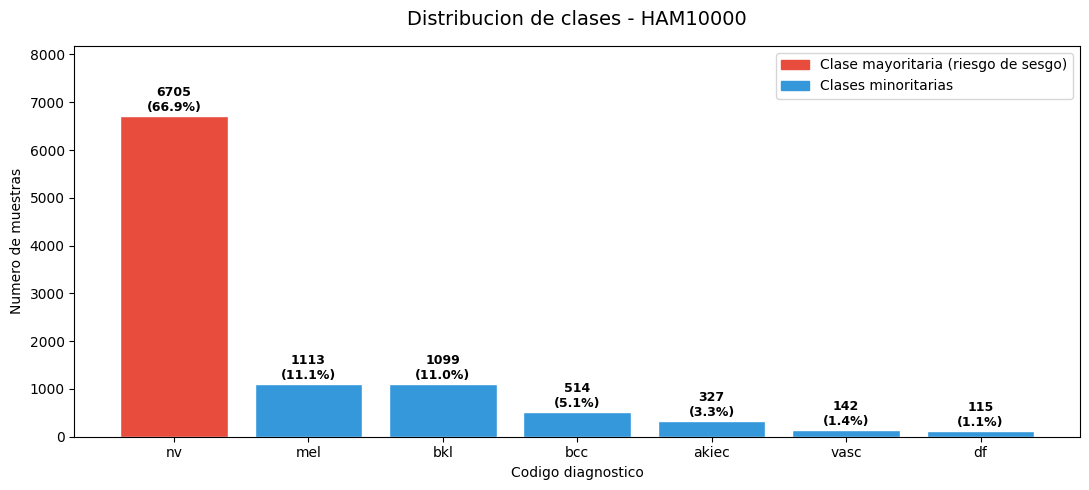

Codigo           Diagnostico  Muestras Porcentaje
    nv    Nevus melanocitico      6705      66.9%
   mel              Melanoma      1113      11.1%
   bkl    Queratosis benigna      1099      11.0%
   bcc Carcinoma basocelular       514       5.1%
 akiec   Queratosis actinica       327       3.3%
  vasc       Lesion vascular       142       1.4%
    df        Dermatofibroma       115       1.1%

Total: 10015 muestras
La clase nv representa el 66.9% del dataset.
Un modelo que prediga siempre nv tendria ese % de accuracy sin aprender nada (baseline ZeroR).


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv(r'../data/raw/HAM10000_metadata.csv')

class_names = {
    'nv':    'Nevus melanocitico',
    'mel':   'Melanoma',
    'bkl':   'Queratosis benigna',
    'bcc':   'Carcinoma basocelular',
    'akiec': 'Queratosis actinica',
    'vasc':  'Lesion vascular',
    'df':    'Dermatofibroma'
}

counts = df['dx'].value_counts()
pcts   = df['dx'].value_counts(normalize=True) * 100
colors = ['#e74c3c' if c == 'nv' else '#3498db' for c in counts.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Distribucion de clases - HAM10000', fontsize=14, pad=15)
ax.set_xlabel('Codigo diagnostico')
ax.set_ylabel('Numero de muestras')
ax.set_ylim(0, counts.max() * 1.22)
leyenda = [
    mpatches.Patch(color='#e74c3c', label='Clase mayoritaria (riesgo de sesgo)'),
    mpatches.Patch(color='#3498db', label='Clases minoritarias')
]
ax.legend(handles=leyenda, loc='upper right')
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Codigo':      counts.index,
    'Diagnostico': [class_names[c] for c in counts.index],
    'Muestras':    counts.values,
    'Porcentaje':  [f'{p:.1f}%' for p in pcts.values]
})
print(summary.to_string(index=False))
print(f'\nTotal: {len(df)} muestras')
print(f'La clase nv representa el {pcts["nv"]:.1f}% del dataset.')
print('Un modelo que prediga siempre nv tendria ese % de accuracy sin aprender nada (baseline ZeroR).')

## Distribucion de edad y outliers

La edad es la unica variable numerica continua del dataset. Conviene ver:
- Si hay valores nulos (necesitan imputacion antes de entrenar)
- Como se distribuye la edad en general
- Si la distribucion varia entre diagnosticos (puede aportar informacion al modelo)
- Si hay **outliers**: valores extremos que podrian distorsionar la normalizacion

> En un **boxplot**, los puntos que aparecen fuera de los bigotes son outliers.

C:\Users\rammu\AppData\Local\Temp\ipykernel_2208\298579058.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_by_class, labels=counts.index, patch_artist=True)


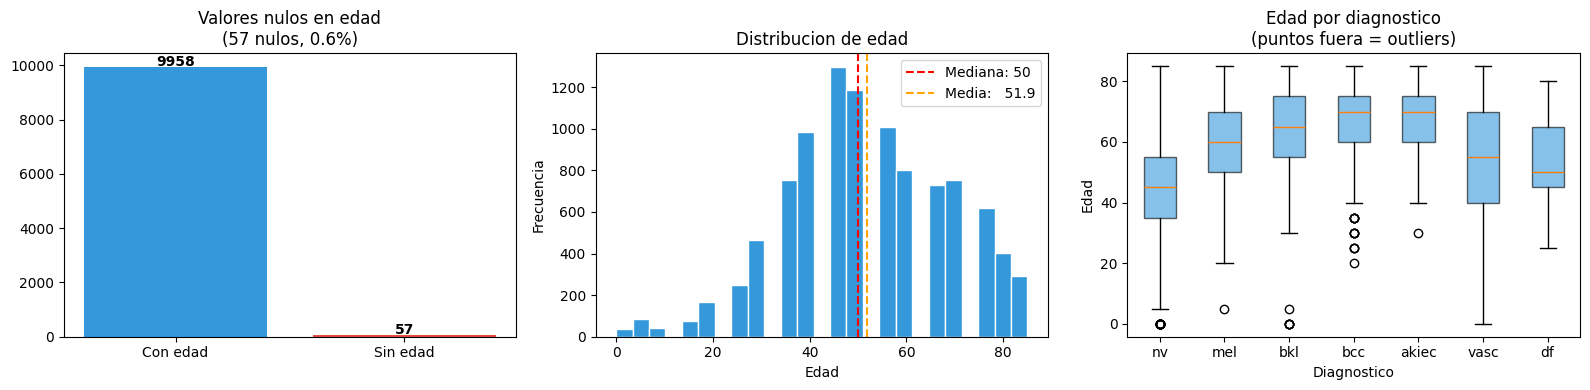

Estadisticas de edad:
count    9958.0
mean       51.9
std        17.0
min         0.0
25%        40.0
50%        50.0
75%        65.0
max        85.0

Imputaremos los 57 nulos con la MEDIANA (50 anios),
mas robusta que la media cuando hay outliers (pacientes jovenes/muy mayores).


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Valores nulos
null_count = df['age'].isna().sum()
null_pct   = df['age'].isna().mean() * 100
axes[0].bar(['Con edad', 'Sin edad'], [len(df) - null_count, null_count],
            color=['#3498db', '#e74c3c'])
axes[0].set_title(f'Valores nulos en edad\n({null_count} nulos, {null_pct:.1f}%)')
for i, v in enumerate([len(df) - null_count, null_count]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# 2. Histograma de edad
mediana = df['age'].median()
media   = df['age'].mean()
axes[1].hist(df['age'].dropna(), bins=25, color='#3498db', edgecolor='white')
axes[1].axvline(mediana, color='red',    linestyle='--', label=f'Mediana: {mediana:.0f}')
axes[1].axvline(media,   color='orange', linestyle='--', label=f'Media:   {media:.1f}')
axes[1].set_title('Distribucion de edad')
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Boxplot por clase
data_by_class = [df[df['dx'] == cls]['age'].dropna().values for cls in counts.index]
bp = axes[2].boxplot(data_by_class, labels=counts.index, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db'); patch.set_alpha(0.6)
axes[2].set_title('Edad por diagnostico\n(puntos fuera = outliers)')
axes[2].set_xlabel('Diagnostico'); axes[2].set_ylabel('Edad')

plt.tight_layout()
plt.show()

print('Estadisticas de edad:')
print(df['age'].describe().round(1).to_string())
print(f'\nImputaremos los {null_count} nulos con la MEDIANA ({mediana:.0f} anios),')
print('mas robusta que la media cuando hay outliers (pacientes jovenes/muy mayores).')

## Distribucion de variables categoricas

Sexo y localizacion se codificaran como variables one-hot antes de entrenar.
Conviene ver si alguna categoria tiene muy pocos ejemplos, lo que la haria poco informativa.

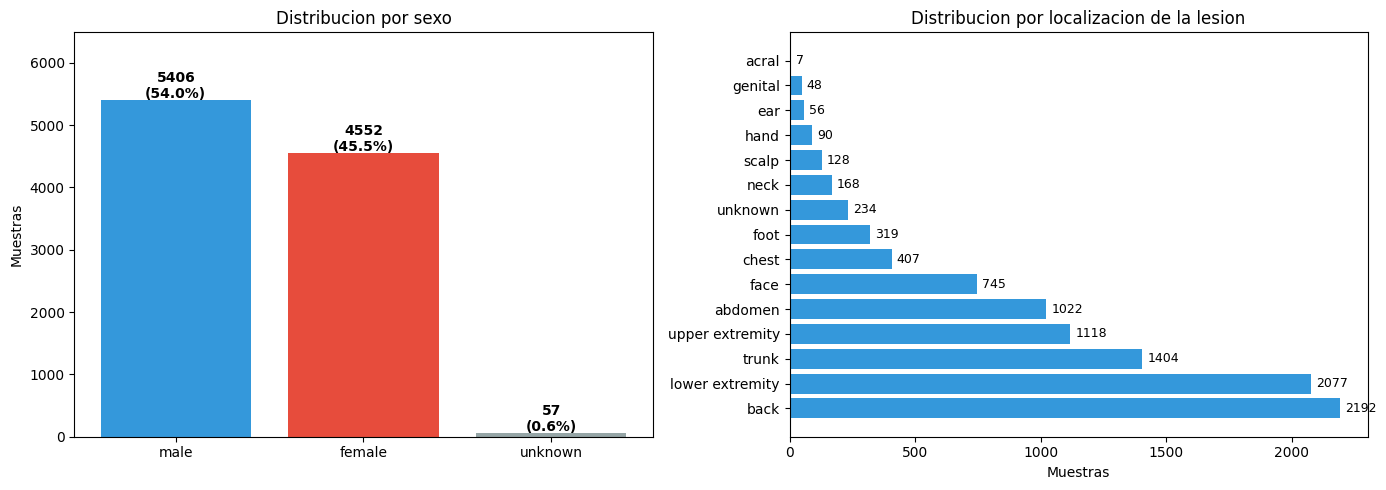

Categorias en sexo: ['male', 'female', 'unknown']
Categorias en localizacion: 15 valores distintos


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sexo
sex_counts = df['sex'].value_counts()
bars = axes[0].bar(sex_counts.index, sex_counts.values,
                   color=['#3498db', '#e74c3c', '#95a5a6'])
axes[0].set_title('Distribucion por sexo')
axes[0].set_ylabel('Muestras')
for bar, count in zip(bars, sex_counts.values):
    pct = count / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, sex_counts.max() * 1.2)

# Localizacion
loc_counts = df['localization'].value_counts()
axes[1].barh(loc_counts.index, loc_counts.values, color='#3498db')
axes[1].set_title('Distribucion por localizacion de la lesion')
axes[1].set_xlabel('Muestras')
for i, count in enumerate(loc_counts.values):
    axes[1].text(count + 20, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Categorias en sexo: {list(df["sex"].unique())}')
print(f'Categorias en localizacion: {df["localization"].nunique()} valores distintos')

## Muestra visual de imágenes

Comprobamos que las imágenes se carguen correctamente y tienen el aspecto esperado (28×28 píxeles RGB).

Clases: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


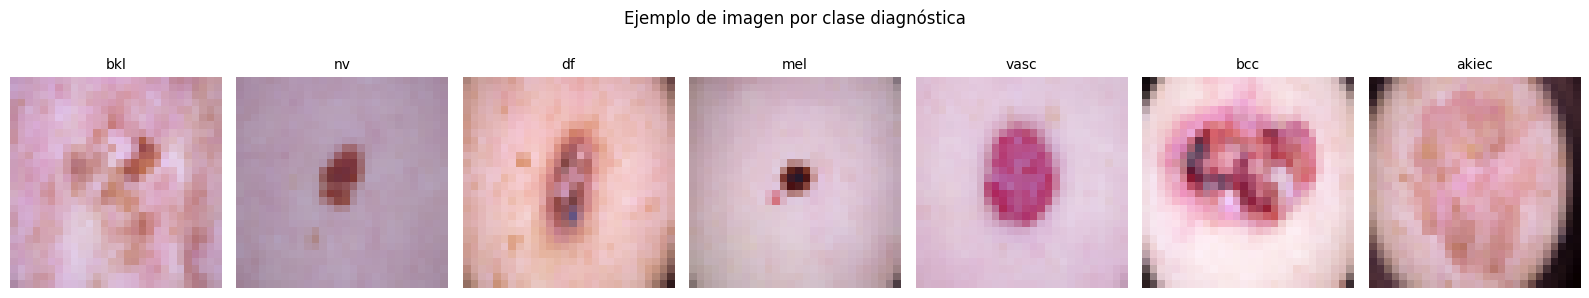

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargamos los datos necesarios para la visualización
df_images   = pd.read_csv(r"../data/raw/hnmist_28_28_RGB.csv")
df_metadata = pd.read_csv(r"../data/raw/HAM10000_metadata.csv")

clases = df_metadata['dx'].unique()
print(f"Clases: {clases}")

# Mostramos una imagen de ejemplo por cada clase
fig, axes = plt.subplots(1, len(clases), figsize=(16, 3))
for ax, clase in zip(axes, clases):
    idx = df_metadata[df_metadata['dx'] == clase].index[0]
    img = df_images.iloc[idx].values.reshape(28, 28, 3).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(clase, fontsize=10)
    ax.axis('off')

plt.suptitle('Ejemplo de imagen por clase diagnóstica', y=1.02)
plt.tight_layout()
plt.show()

## Conclusiones del EDA

- El dataset tiene **10.015 muestras** de 7 clases de lesiones cutáneas.
- **Desbalanceo de clases notable**: la clase `nv` (nevus) representa ~67% de los datos.
- La columna `age` tiene valores nulos que se imputarán con la mediana.
- Las imágenes están preprocesadas a 28×28 píxeles RGB y almacenadas como CSV.
- Estas observaciones justifican el uso de `stratify` en el split y la imputación por mediana.